In [1]:
import numpy as np

# Sample dataset (0 or 1)
X = np.array([[0], [1], [2], [3], [4], [5]])
y = np.array([0, 0, 0, 1, 1, 1])

# Initialize parameters
w = 0.0
b = 0.0
lr = 0.1
epochs = 1000

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Training loop
for epoch in range(epochs):
    # Forward pass
    z = w * X + b
    y_pred = sigmoid(z)
    
    # Compute loss (binary cross-entropy)
    loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
    
    # Compute gradients
    dw = np.mean((y_pred - y) * X)
    db = np.mean(y_pred - y)
    
    # Update weights
    w -= lr * dw
    b -= lr * db
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, w: {w:.4f}, b: {b:.4f}")

# Prediction
preds = sigmoid(w * X + b) >= 0.5
print("Predicted classes:", preds.astype(int))

Epoch 0, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 100, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 200, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 300, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 400, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 500, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 600, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 700, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 800, Loss: 0.6931, w: 0.0000, b: 0.0000
Epoch 900, Loss: 0.6931, w: 0.0000, b: 0.0000
Predicted classes: [[1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [2]:
import tensorflow as tf
import numpy as np

# Dataset
X = np.array([[0], [1], [2], [3], [4], [5]], dtype=np.float32)
y = np.array([[0], [0], [0], [1], [1], [1]], dtype=np.float32)

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,), activation='sigmoid')
])

# Compile
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X, y, epochs=1000, verbose=0)

# Predict
preds = (model.predict(X) > 0.5).astype(int)
print("Predicted classes:", preds.flatten())

2026-03-02 11:28:54.912084: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/yengsebastian/Documents/tensorflow/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted classes: [0 0 1 1 1 1]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Create simple 2D dataset
# ----------------------------

np.random.seed(42)

# Class 0
X0 = np.random.randn(50, 2) + np.array([-2, -2])
y0 = np.zeros((50, 1))

# Class 1
X1 = np.random.randn(50, 2) + np.array([2, 2])
y1 = np.ones((50, 1))

# Combine
X = np.vstack((X0, X1))
y = np.vstack((y0, y1))

# ----------------------------
# 2️⃣ Initialize parameters
# ----------------------------

w = np.random.randn(2, 1)
b = 0.0
lr = 0.1
epochs = 1000

# ----------------------------
# 3️⃣ Sigmoid
# ----------------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ----------------------------
# 4️⃣ Training loop
# ----------------------------

losses = []

for _ in range(epochs):
    
    # Forward pass
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    
    # Binary Cross Entropy
    loss = -np.mean(y * np.log(y_hat + 1e-8) + 
                    (1 - y) * np.log(1 - y_hat + 1e-8))
    losses.append(loss)
    
    # Gradients
    dw = np.dot(X.T, (y_hat - y)) / len(X)
    db = np.mean(y_hat - y)
    
    # Update
    w -= lr * dw
    b -= lr * db

print("Final Loss:", losses[-1])

Final Loss: 0.003802110975502162


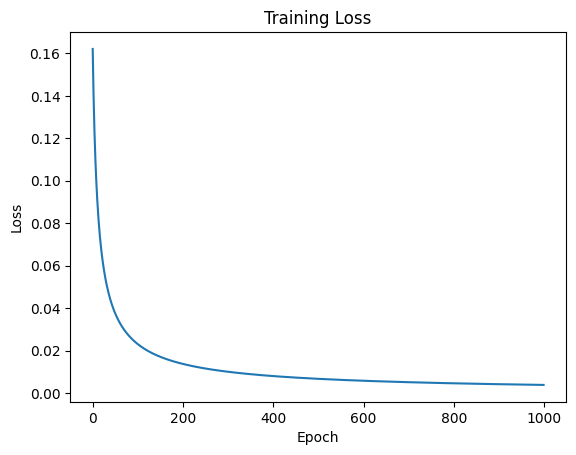

In [3]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

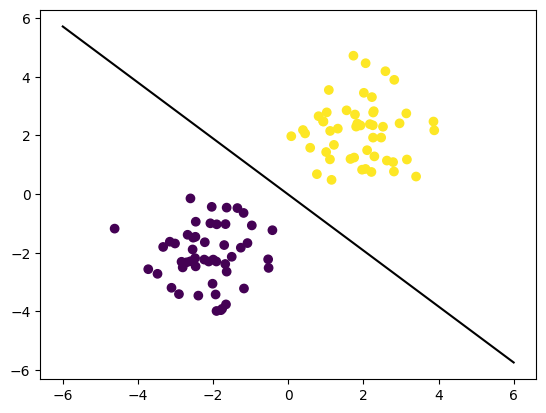

In [4]:
plt.scatter(X[:,0], X[:,1], c=y.flatten())

# Decision boundary
x_values = np.linspace(-6, 6, 100)
y_values = -(w[0] * x_values + b) / w[1]

plt.plot(x_values, y_values, color="black")
plt.show()


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Recreate same dataset
# ----------------------------

np.random.seed(42)

X0 = np.random.randn(50, 2) + np.array([-2, -2])
y0 = np.zeros((50, 1))

X1 = np.random.randn(50, 2) + np.array([2, 2])
y1 = np.ones((50, 1))

X = np.vstack((X0, X1)).astype(np.float32)
y = np.vstack((y0, y1)).astype(np.float32)

# ----------------------------
# 2️⃣ Build model
# ----------------------------

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy"
)

# ----------------------------
# 3️⃣ Train
# ----------------------------

history = model.fit(X, y, epochs=1000, verbose=0)

print("Final Loss:", history.history["loss"][-1])

2026-03-03 18:05:14.738817: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Final Loss: 0.0011247817892581224


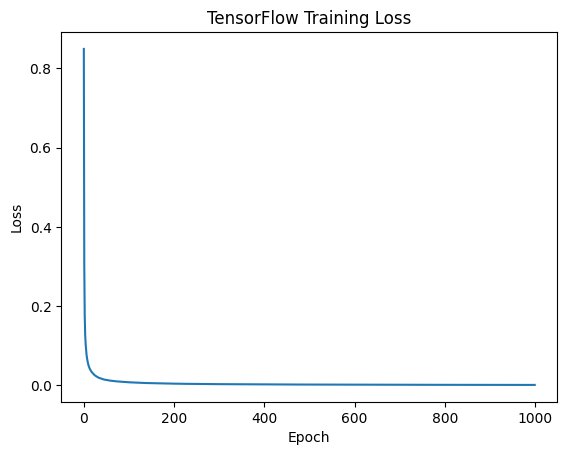

In [6]:
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Training Loss")
plt.show()

In [7]:
weights, bias = model.layers[0].get_weights()

print("Weights:\n", weights)
print("Bias:\n", bias)

Weights:
 [[3.0129676]
 [2.151093 ]]
Bias:
 [0.15301488]


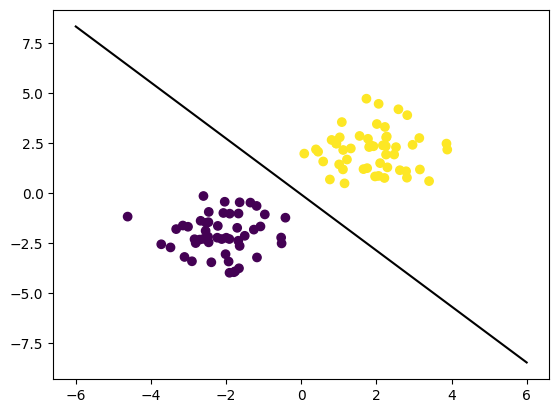

In [8]:
plt.scatter(X[:,0], X[:,1], c=y.flatten())

x_values = np.linspace(-6, 6, 100)
y_values = -(weights[0] * x_values + bias) / weights[1]

plt.plot(x_values, y_values, color="black")
plt.show()

In [9]:
import tensorflow as tf
import numpy as np

emails = [
    "Win a free lottery now",
    "Congratulations you won money",
    "Claim your free prize",
    "Meeting at 10am tomorrow",
    "Can we reschedule our call?",
    "Project deadline reminder"
]

labels = [1, 1, 1, 0, 0, 0]  # 1 = spam, 0 = not spam

In [10]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(emails)

X = tokenizer.texts_to_sequences(emails)

In [11]:
X = tf.keras.preprocessing.sequence.pad_sequences(X)
y = np.array(labels)

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=1000, output_dim=8),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(X, y, epochs=20, verbose=1)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6953
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5000 - loss: 0.6939
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6667 - loss: 0.6924
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6667 - loss: 0.6909
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.6667 - loss: 0.6894
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6667 - loss: 0.6879
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6667 - loss: 0.6865
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6667 - loss: 0.6850
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8333 - loss: 0.6835
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8333 - loss: 0.6820
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.6806
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.6791
Epo

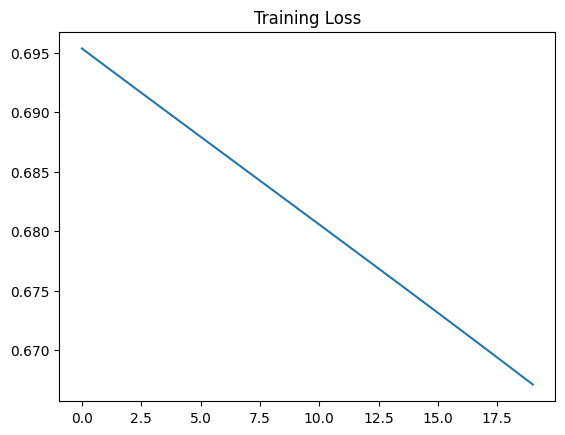

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.show()

In [17]:
test_email = ["I think we will be having a meething this night."]
seq = tokenizer.texts_to_sequences(test_email)
padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=X.shape[1])

prediction = model.predict(padded)

print("Spam Probability:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Spam Probability: 0.4874093
